# Customer Churn Prediction
**IBM Telco Dataset · Logistic Regression · scikit-learn**

Predicting which customers are likely to cancel their subscription, 
enabling proactive retention strategies. This project covers the full 
ML workflow: EDA, preprocessing, modeling, threshold optimization, and evaluation.

**Key results:** 79% recall on churn class · 0.83 ROC-AUC · Threshold tuned to 0.3

### Methodology

The project follows these steps:

1. Exploratory Data Analysis (EDA)  
2. Data cleaning and preprocessing  
3. Feature encoding (One-Hot Encoding and Ordinal Encoding)  
4. Model training using Logistic Regression  
5. Handling class imbalance using `class_weight`  
6. Threshold tuning to improve churn detection  
7. Model evaluation using classification metrics and ROC-AUC  

---

### Results

- ROC-AUC: ~0.83  
- Improved recall for churn detection through threshold adjustment  
- Balanced performance between precision and recall  

The model shows a strong ability to identify customers at risk of churn.

---

### Key Insights

- Customers with month-to-month contracts show higher churn rates  
- Higher monthly charges are associated with increased churn risk  
- Lack of additional services (e.g., tech support) may increase churn probability  

---

###  Conclusion

The model can be used as a base for implementing customer retention strategies focused on high-risk users.

It prioritizes recall to reduce the number of missed churn cases, aligning with business impact.

The model can be further improved with additional data and features.

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("Customer_Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 1. Exploratory Data Analysis
> Goal: understand the distribution of key variables and identify 
> early signals of churn before modeling.

In [3]:
# It's crucial to note the data type of the most important features.
# The relevant variables are: Tenures, Monthly charge and contract.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Very important to observe if there's any noise or useless values inside our data set e.g NaN.
df.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

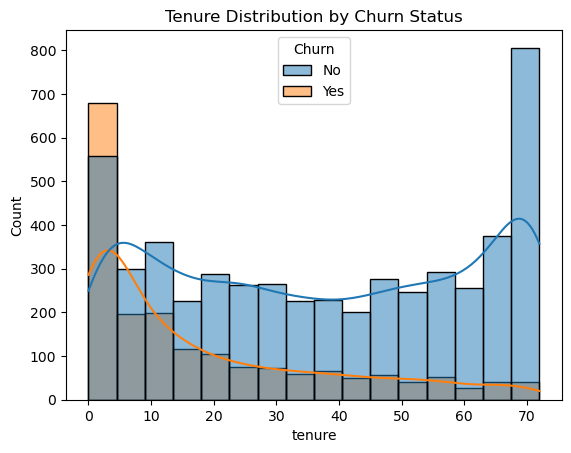

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="tenure", hue="Churn", kde=True)
plt.title("Tenure Distribution by Churn Status")
plt.show()

In [6]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

#### Key Variables Analysis

##### Tenure
Customers with shorter tenure tend to exhibit higher churn rates.

##### Monthly Charges
Higher monthly charges are associated with increased churn rates.

##### Contract
Month-to-month contracts present a higher churn risk.

##### Tech Support
Service quality and technical support play an important role in customer retention.

##### Payment Method
Payment habits that may create friction and increase churn risk.

##### Internet Service
Reflects the customer's service experience.

**Insight:** New customers, high costs and short time contracts are the clearer features to study and train our model with.

## 2. Data Cleaning & Preprocessing
Selected features based on business relevance and correlation with churn.

Categorical variables encoded for compatibility with Logistic Regression.

In [7]:
cols_2_drop = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'StreamingTV', 'StreamingMovies', 
               'DeviceProtection', 'PaperlessBilling', 'TotalCharges']

df = df.drop(columns=cols_2_drop)

> **Feature selection rationale:** Demographic variables (gender, SeniorCitizen, 
> Dependents) showed low correlation with churn in EDA. 
> `customerID` is an identifier with no predictive value. 
> `TotalCharges` was excluded from this baseline model to
> maintain a simpler and more interpretable feature set.

In [8]:
df

,tenure,InternetService,TechSupport,Contract,PaymentMethod,MonthlyCharges,Churn
0,1,DSL,No,Month-to-month,Electronic check,29.85,No
1,34,DSL,No,One year,Mailed check,56.95,No
2,2,DSL,No,Month-to-month,Mailed check,53.85,Yes
3,45,DSL,Yes,One year,Bank transfer (automatic),42.30,No
4,2,Fiber optic,No,Month-to-month,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...
7038,24,DSL,Yes,One year,Mailed check,84.80,No
7039,72,Fiber optic,No,One year,Credit card (automatic),103.20,No
7040,11,DSL,No,Month-to-month,Electronic check,29.60,No
7041,4,Fiber optic,No,Month-to-month,Mailed check,74.40,Yes


##### It's necessary to transform our categorical variables to an understandable format for our model.

In [9]:
df = pd.get_dummies(df, columns=["InternetService"], drop_first=True)
df = pd.get_dummies(df, columns=["TechSupport"], drop_first=True)
df = pd.get_dummies(df, columns=["PaymentMethod"], drop_first=True)

In [10]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[[
    "Month-to-month", "One year", "Two year"
]])

df[["Contract"]] = encoder.fit_transform(df[["Contract"]])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   Contract                               7043 non-null   float64
 2   MonthlyCharges                         7043 non-null   float64
 3   Churn                                  7043 non-null   object 
 4   InternetService_Fiber optic            7043 non-null   bool   
 5   InternetService_No                     7043 non-null   bool   
 6   TechSupport_No internet service        7043 non-null   bool   
 7   TechSupport_Yes                        7043 non-null   bool   
 8   PaymentMethod_Credit card (automatic)  7043 non-null   bool   
 9   PaymentMethod_Electronic check         7043 non-null   bool   
 10  PaymentMethod_Mailed check             7043 non-null   bool   
dtypes: b

##### There still the dependant variable (churn) and transforming the bool objects to int.

In [13]:
df["Churn"] = df["Churn"].map({
    "No": 0, 
    "Yes": 1
})

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   Contract                               7043 non-null   float64
 2   MonthlyCharges                         7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   InternetService_Fiber optic            7043 non-null   bool   
 5   InternetService_No                     7043 non-null   bool   
 6   TechSupport_No internet service        7043 non-null   bool   
 7   TechSupport_Yes                        7043 non-null   bool   
 8   PaymentMethod_Credit card (automatic)  7043 non-null   bool   
 9   PaymentMethod_Electronic check         7043 non-null   bool   
 10  PaymentMethod_Mailed check             7043 non-null   bool   
dtypes: b

In [15]:
df

,tenure,Contract,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,TechSupport_No internet service,TechSupport_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0.0,29.85,0,False,False,False,False,False,True,False
1,34,1.0,56.95,0,False,False,False,False,False,False,True
2,2,0.0,53.85,1,False,False,False,False,False,False,True
3,45,1.0,42.30,0,False,False,False,True,False,False,False
4,2,0.0,70.70,1,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
7038,24,1.0,84.80,0,False,False,False,True,False,False,True
7039,72,1.0,103.20,0,True,False,False,False,True,False,False
7040,11,0.0,29.60,0,False,False,False,False,False,True,False
7041,4,0.0,74.40,1,True,False,False,False,False,False,True


##### To finish with preparation, we separate the train and test set.

In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_, y_test = train_test_split(X, y, test_size = 0.4, random_state=137)

## 3. ML model creation

In [18]:
from sklearn.linear_model import LogisticRegression

CxCh = LogisticRegression(max_iter = 1000)
CxCh.fit(X_train, y_train_)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 4. Model evaluation

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = CxCh.predict(X_test)
y_prob = CxCh.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      2050
           1       0.65      0.47      0.55       768

    accuracy                           0.79      2818
   macro avg       0.74      0.69      0.70      2818
weighted avg       0.77      0.79      0.78      2818

ROC-AUC: 0.833603912601626


> **Interpretation:** Default threshold (0.5) achieves only 47% recall on the churn 
> class — meaning the model misses more than half of customers who will actually leave. 
> For a retention use case, this is unacceptable. We optimize the threshold next.

In [20]:
probabilidades = [0.2, 0.3, 0.4, 0.55, 0.6]

for l in probabilidades:
    y_prob = CxCh.predict_proba(X_test)[:, 1]
    y_pred_l = (y_prob > l).astype(int)
    print(f"\n Threshold: {l}")
    print(classification_report(y_test, y_pred_l))


 Threshold: 0.2
              precision    recall  f1-score   support

           0       0.91      0.66      0.77      2050
           1       0.48      0.83      0.61       768

    accuracy                           0.71      2818
   macro avg       0.70      0.75      0.69      2818
weighted avg       0.79      0.71      0.73      2818


 Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      2050
           1       0.55      0.75      0.63       768

    accuracy                           0.76      2818
   macro avg       0.72      0.76      0.73      2818
weighted avg       0.80      0.76      0.77      2818


 Threshold: 0.4
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2050
           1       0.61      0.61      0.61       768

    accuracy                           0.79      2818
   macro avg       0.73      0.73      0.73      2818
weighted avg       0.79

> **Selected threshold: 0.3**  
> At this point, recall on churn rises to 75% while precision remains at 0.55. 
> The business trade-off: for every 100 customers flagged as at-risk, 
> ~55 will actually churn. This is acceptable given that the cost of missing 
> a churner (lost revenue) typically exceeds the cost of a false alarm (a retention offer).

In [21]:
CxCh = LogisticRegression(class_weight={0:1, 1:2}, max_iter=1000)
CxCh.fit(X_train, y_train_)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 2}"
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
y_pred = CxCh.predict(X_test)
y_prob = CxCh.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      2050
           1       0.57      0.71      0.63       768

    accuracy                           0.78      2818
   macro avg       0.73      0.76      0.74      2818
weighted avg       0.80      0.78      0.78      2818

ROC-AUC: 0.8332831554878048


##### We perform the same exploratory exercise involving testing with different decision thresholds:

In [23]:
probabilidades = [0.2, 0.3, 0.4, 0.55, 0.6]

for l in probabilidades:
    y_prob = CxCh.predict_proba(X_test)[:, 1]
    y_pred_l = (y_prob > l).astype(int)
    print(f"\n Threshold: {l}")
    print(classification_report(y_test, y_pred_l))


 Threshold: 0.2
              precision    recall  f1-score   support

           0       0.95      0.52      0.67      2050
           1       0.42      0.93      0.58       768

    accuracy                           0.63      2818
   macro avg       0.68      0.72      0.62      2818
weighted avg       0.80      0.63      0.64      2818


 Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.64      0.75      2050
           1       0.47      0.84      0.60       768

    accuracy                           0.69      2818
   macro avg       0.69      0.74      0.68      2818
weighted avg       0.79      0.69      0.71      2818


 Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      2050
           1       0.50      0.79      0.61       768

    accuracy                           0.73      2818
   macro avg       0.70      0.75      0.70      2818
weighted avg       0.79

## 5. Metric visualization

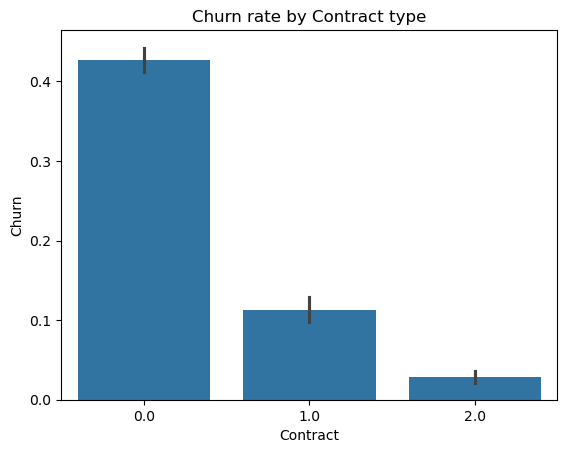

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Churn rate by Contract type")
plt.show()

##### Observation:
There is a clear tendency towards churn if the contract type is "Month-to-month". Similarly, there is a considerable number of employees in the other two options that are well worth retaining.

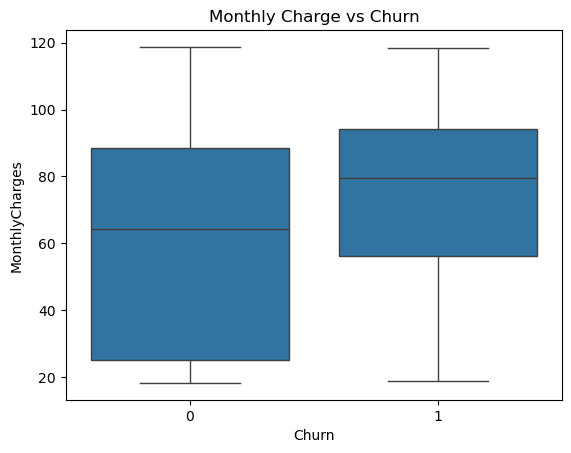

In [25]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charge vs Churn")
plt.show()

##### Observation:
Customers with higher monthly charges tend to churn.

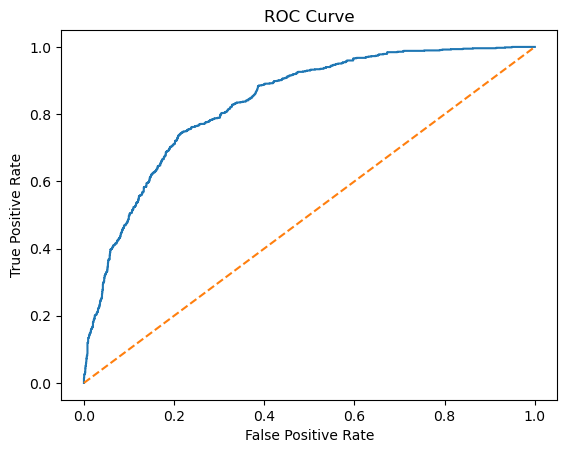

In [26]:
from sklearn.metrics import roc_curve

fpr,tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##### Observation:
Note how the curve is significantly higher than the diagonal, indicating that the model has a good balance between detecting churn and avoiding false positives.

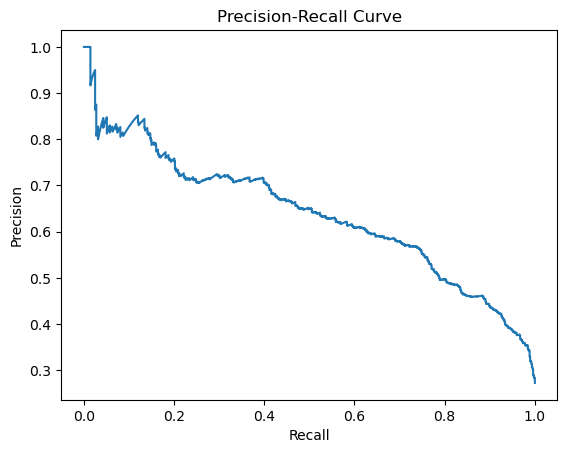

In [27]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## 6. Conclusions

### Model

The logistic regression model with class weighting successfully identifies customers at risk of churn based on three main signal groups: contract terms, billing behavior, and service usage patterns. Despite its simplicity, the model provides an interpretable and actionable baseline for a customer retention strategy.

---

### Class imbalance & threshold tuning

The dataset is imbalanced — churn cases represent roughly 26% of the total — which causes a default model to systematically underpredict churn. Two strategies were applied to address this:

- **Class weighting `{0:1, 1:2}`:** penalizes misclassifying a churner twice as much as misclassifying a non-churner, shifting the model's decision boundary toward higher recall.
- **Threshold tuning:** instead of using the default 0.5 cutoff, five thresholds were evaluated (0.2 → 0.6). A threshold of **0.3** was selected as the optimal operating point.

> **Why 0.3?** At this threshold, churn recall reaches **75%** while precision remains at 0.55. The business trade-off is acceptable: for every 100 customers flagged as at-risk, roughly 55 will actually churn. Missing a churner (lost revenue) typically costs more than a false alarm (an unnecessary retention offer), so prioritizing recall is the right call here.

---

### Recall

Recall on the churn class improved from **47%** (default threshold, no class weighting) to **75%** after applying both adjustments. This means the model now correctly identifies 3 out of 4 customers who would have left — a meaningful improvement for any retention campaign that needs to prioritize outreach.

The precision–recall trade-off is expected and intentional: as recall increases, precision decreases. The steepest drop in the precision-recall curve occurs between recall values of 0.7 and 0.8, which confirms that 0.3 is near the practical efficiency frontier for this model.

---

### Key patterns identified

| Feature | Pattern |
|---|---|
| Contract type | Month-to-month customers churn at ~43% — far above one-year (11%) and two-year (3%) |
| Monthly charges | Churners show a higher median monthly charge, suggesting price sensitivity |
| Tech support | Absence of tech support is associated with higher churn probability |
| Payment method | Electronic check users show higher churn, possibly indicating lower commitment |

---

### Limitations

- **Feature scope:** Several potentially predictive features were excluded during preprocessing (`OnlineSecurity`, `OnlineBackup`, `TotalCharges` after proper cleaning). A future version should retain and clean these rather than drop them.
- **Single model:** Only Logistic Regression was evaluated. Tree-based models such as Random Forest or XGBoost would likely improve recall without sacrificing as much precision, and would capture non-linear interactions between features.
- **No deployment:** The model currently lives only in this notebook. A Streamlit interface would allow non-technical stakeholders to query churn risk interactively for individual customers.
- **Static dataset:** The model was trained on a single snapshot. In production, churn patterns shift over time and the model would need periodic retraining.

---

### Final takeaway

This model can serve as a functional baseline for a customer retention pipeline. By flagging the roughly 600 highest-risk customers in this dataset, a retention team could prioritize outreach and potentially recover a significant share of revenue that would otherwise be lost to churn. Further gains are achievable with richer features, ensemble methods, and a proper train/validation/test split strategy.